In [ ]:
%pip install matplotlib
%pip install seaborn


1. Importar as bibliotecas


In [2]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns


2. Definir a variável "arquivo" pelo nome da planilha.


In [3]:
arquivo = '../datasets/project-1.xlsx'


3. Ler a planilha no Python. Escolha um nome para armazenar. Escolheremos df


In [4]:
df = pd.read_excel(arquivo)
df


,Escolaridade,Sexo,Idade
0,superior,fem,21
1,superior,masc,28
2,fundamental,masc,13
3,médio,masc,19
4,médio,fem,19
5,superior,fem,27
6,fundamental,masc,16
7,médio,fem,23
8,fundamental,fem,15
9,superior,masc,23


**Gráficos para variáveis quantitativas e qualitativas**


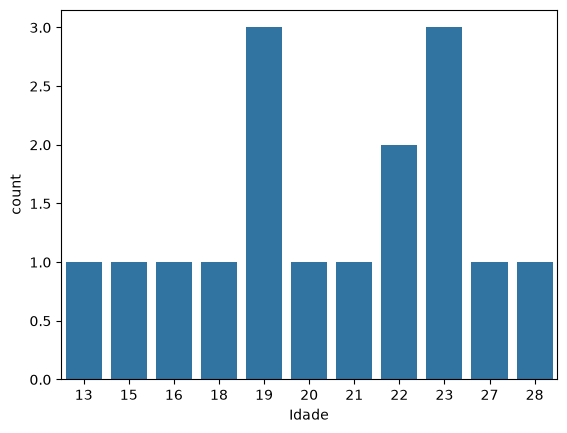

In [5]:
# gráfico de coluna - contando as frequências
sns.countplot(x='Idade', data=df)
plt.show()


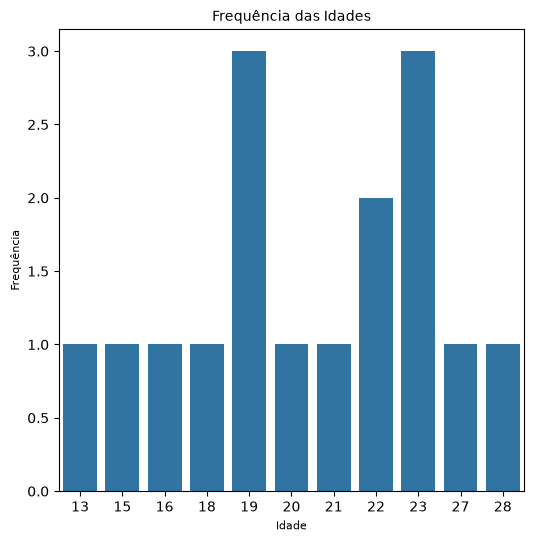

In [6]:
# ajustando os eixos da figura para melhor visualização e dando nomes aos eixos
fig, ax = plt.subplots(figsize=(6, 6))
sns.countplot(x='Idade', data=df)
ax.set_xlabel("Idade", size=8)
ax.set_ylabel("Frequência", size=8)
ax.set_title("Frequência das Idades", size=10)
plt.show()


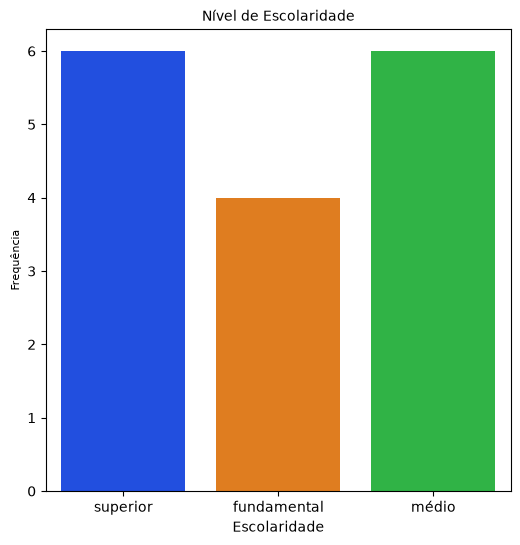

In [7]:

# gráficos de variável qualitativa
# só com o countplot ele não ordena
# ajustando os eixos da figura para melhor visualização e dando nomes aos eixos.
# ajustando cores

fig, ax = plt.subplots(figsize=(6, 6))
sns.countplot(x='Escolaridade', data=df, hue='Escolaridade',
              palette='bright', legend=False)
ax.set_ylabel("Frequência", size=8)
ax.set_title("Nível de Escolaridade", size=10)
plt.show()


In [8]:
# gráficos de variável qualitativa ordenada
df2 = df.Escolaridade.value_counts().sort_index()
df2


Escolaridade
fundamental    4
médio          6
superior       6
Name: count, dtype: int64

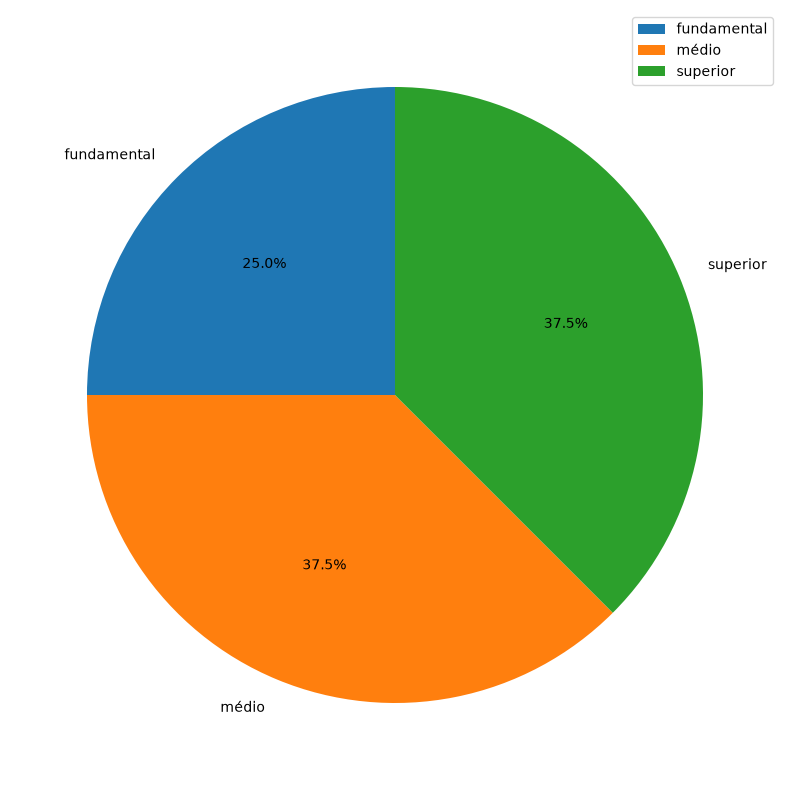

In [9]:
# criando os rótulos e os valores baseados na ordenação anterior
rótulos2 = ['fundamental', 'médio', 'superior']
valores2 = [4, 6, 6]

# criando gráfico de setor
plt.figure(figsize=(10, 10))
plt.pie(valores2, labels=rótulos2, autopct='%1.1f%%', startangle=90)
plt.legend()
plt.show()


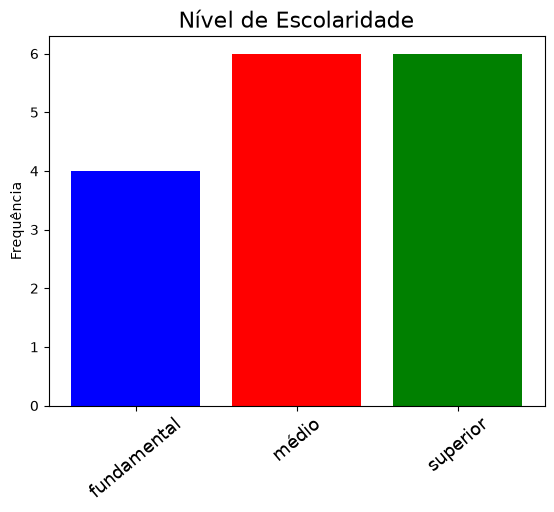

In [10]:
# gráfico de colunas, também usando os rótulos e valores. NESTE CASO ORDENADO POIS rótulos e valores SÃO AS LISTAS JÁ NA ORDEM QUE QUEREMOS.
# escolhendo cores
cores = ['b', 'r', 'g']
plt.bar(rótulos2, valores2, color=cores)
plt.ylabel('Frequência', fontsize=10)
plt.xticks(rótulos2, fontsize=13, rotation=40)
plt.title('Nível de Escolaridade', fontsize=16)
plt.show()


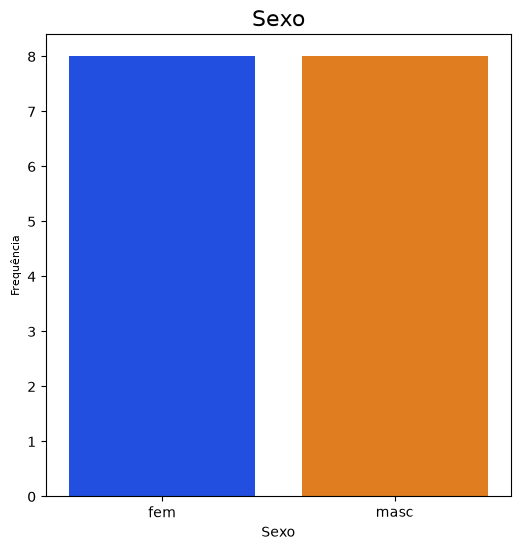

In [11]:
# gráficos de variável qualitativa Sexo (não precisa ordenar)
# ajustando os eixos da figura para melhor visualização e dando nomes aos eixos
fig, ax = plt.subplots(figsize=(6, 6))
sns.countplot(x='Sexo', data=df, hue='Sexo', palette='bright', legend=False)
ax.set_ylabel("Frequência", size=8)
plt.title('Sexo', fontsize=16)
plt.show()


In [12]:
# para gráfico de setor precisamos contar antes
df3 = df.Sexo.value_counts()
df3


Sexo
fem     8
masc    8
Name: count, dtype: int64

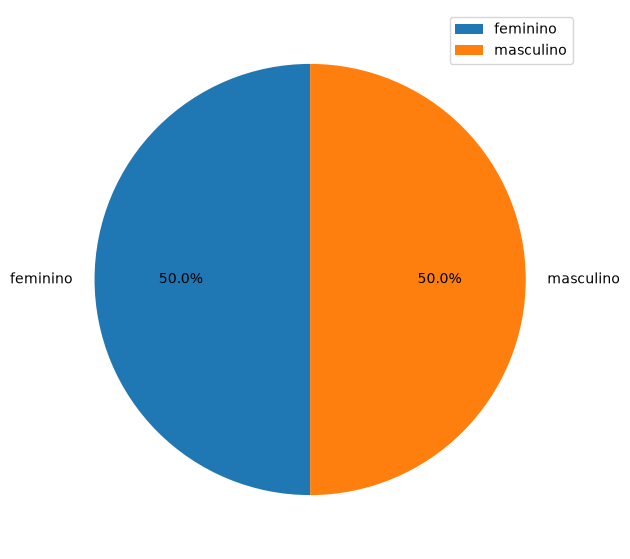

In [13]:
rótulos3 = ['feminino', 'masculino']
valores3 = [8, 8]
plt.figure(figsize=(7, 7))
plt.pie(valores3, labels=rótulos3, autopct='%1.1f%%', startangle=90)
plt.legend()
plt.show()


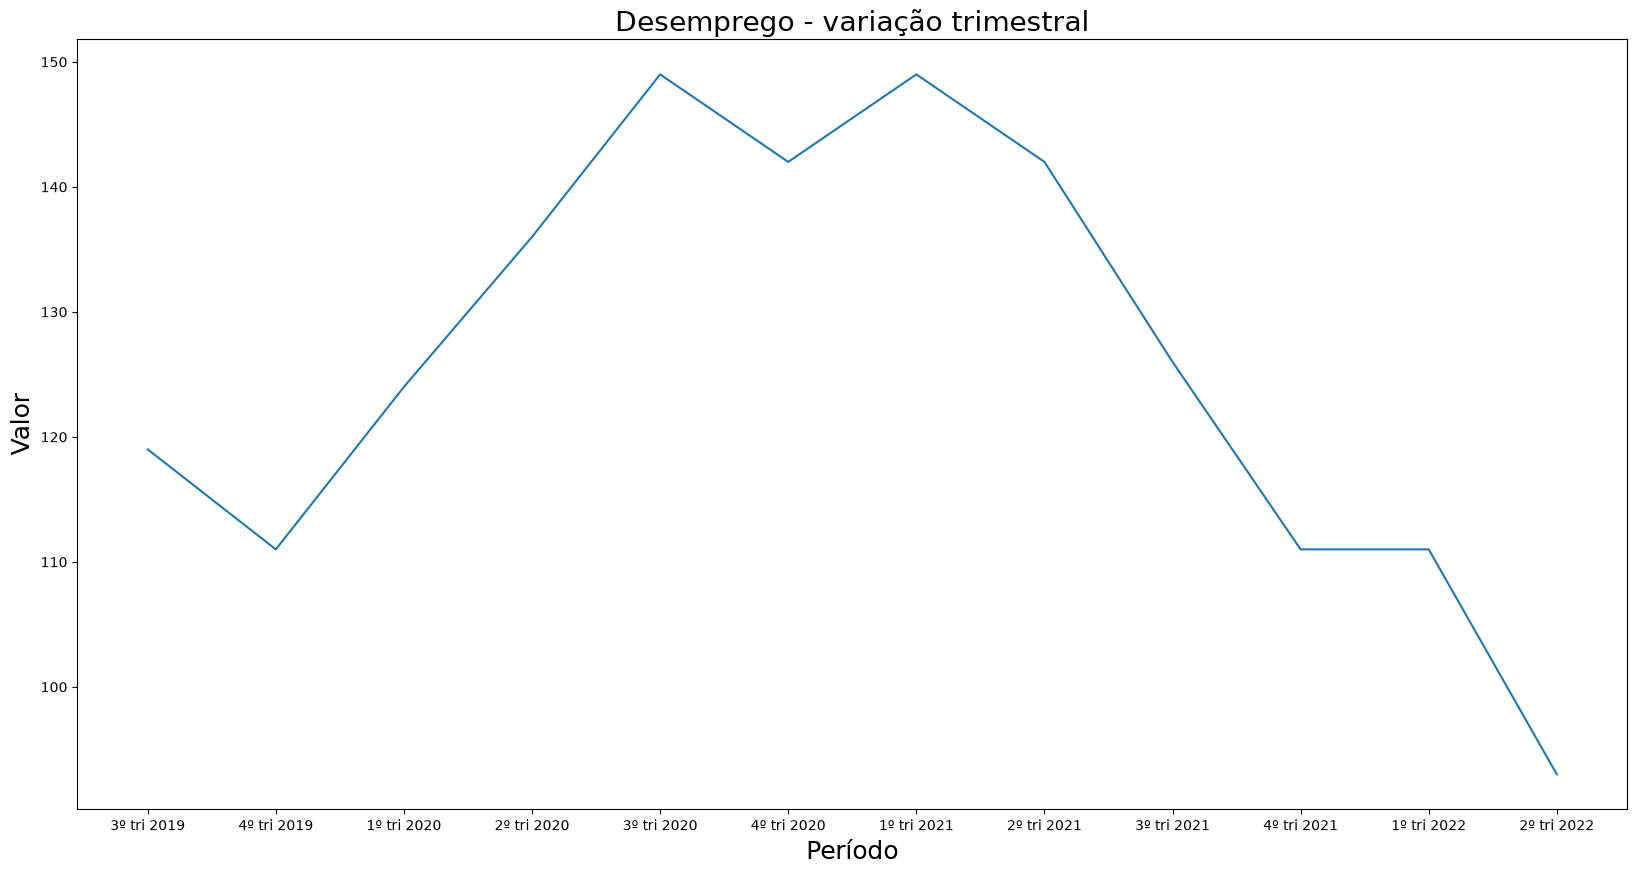

In [14]:
# gráfico de linha (dados com intervalo de tempo)
# usaremos o arquivo obtido do site do IBGE
dados = pd.read_excel('../datasets/unemployment.xlsx')
fig, ax = plt.subplots(figsize=(20, 10))
sns.lineplot(x=dados['periodo'], y=dados['valor'])
ax.set_xlabel("Período", size=18)
ax.set_ylabel("Valor", size=18)
ax.set_title("Desemprego - variação trimestral", size=20)
plt.show()


**Histograma com seaborn e com matplotlib**

Note que o histograma também pode ser feito a partir da tabela de frequência obtida com dados em intervalos de classe. Para isso importe as bibliotecas (matplotlib e seaborn) naquele notebook e utilize as funções.


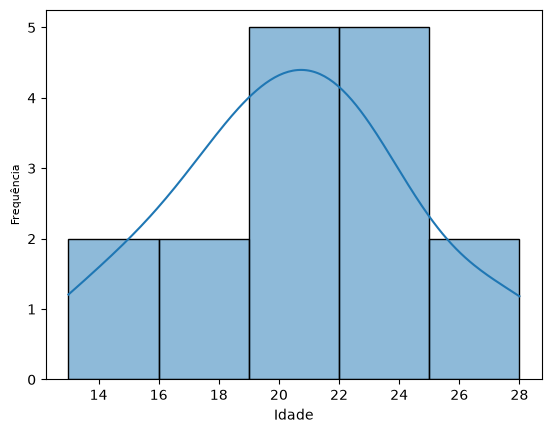

In [15]:
sns.histplot(data=df, x="Idade", kde=True)
plt.ylabel("Frequência", size=8)
plt.show()


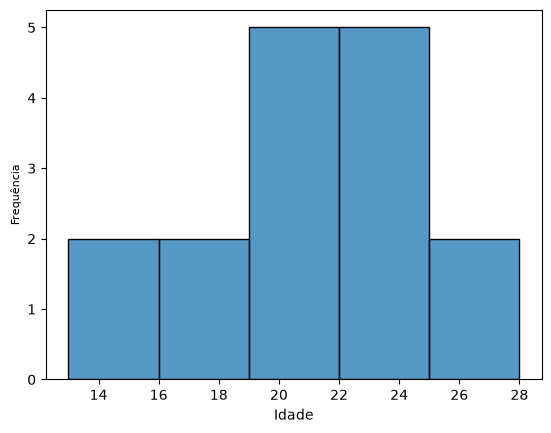

In [16]:
# excluindo a curva que aparece no gráfico
sns.histplot(data=df, x="Idade", kde=False)
plt.ylabel("Frequência", size=8)
plt.show()


PARA FAZERMOS UM HISTOGRAMA É INTERESSANTE SABERMOS OS VALORES MÍNIMO E MÁXIMO DO CONJUNTO DE DADOS.


In [17]:
valormin = min(df.Idade)
valormax = max(df.Idade)
valormin, valormax


(13, 28)

**NO GRÁFICO MONTADO A SEGUIR TOME CUIDADO COM OS EXTREMOS DO INTERVALO. LEMBRE QUE EM PYTHON O INTERVALO À DIREITA É ABERTO (COMO VIMOS NOS COMANDOS DE LISTAS). PORTANTO, SE TEMOS O VALOR MÁXIMO DOS DADOS COMO SENDO 28, ENTÃO TEMOS QUE ESTENDER O INTERVALO PARA O PRÓXIMO INTEIRO.**


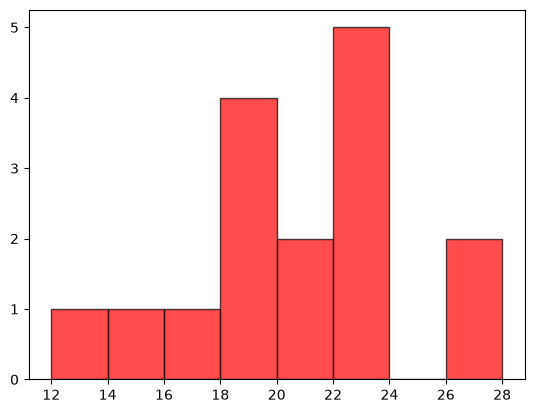

In [18]:
# Construindo o histograma da variável Idade restringindo o tamanho de cada classe. NO EXEMPLO TAMANHO DA CLASSE = 2
classes = range(12, 29, 2)
plt.hist(df.Idade, bins=classes, rwidth=1,
         color='red', alpha=0.7, edgecolor='black')
plt.show()


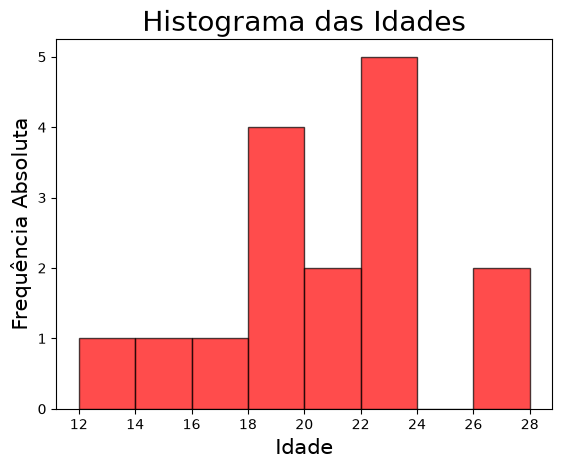

In [19]:
# Incluindo as legendas dos eixos e o título do gráfico
plt.title('Histograma das Idades', fontsize=20)
plt.xlabel('Idade', fontsize=15)
plt.ylabel('Frequência Absoluta', fontsize=15)
plt.tick_params(labelsize=10)
plt.hist(df.Idade, bins=classes, rwidth=1,
         color='red', alpha=0.7, edgecolor='black')
plt.show()


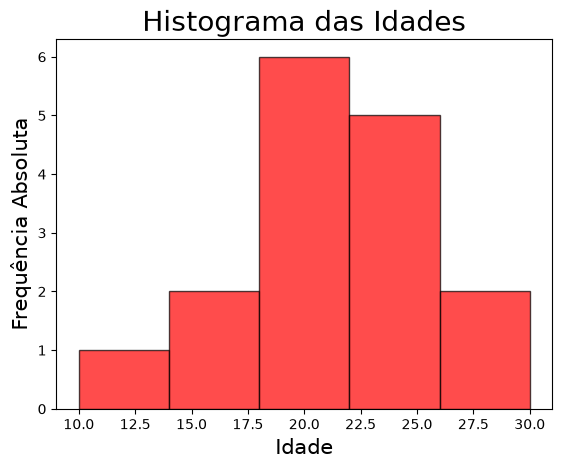

In [20]:
# Construindo o histograma da variável Idade informando os limites inferiores e superiores de cada classe. Lembre de respeitar o valor máximo!!
classes = [10, 14, 18, 22, 26, 30]
plt.hist(df.Idade, bins=classes, rwidth=1,
         color='red', alpha=0.7, edgecolor='black')
# título e legendas
plt.title('Histograma das Idades', fontsize=20)
plt.xlabel('Idade', fontsize=15)
plt.ylabel('Frequência Absoluta', fontsize=15)
plt.tick_params(labelsize=10)
plt.show()


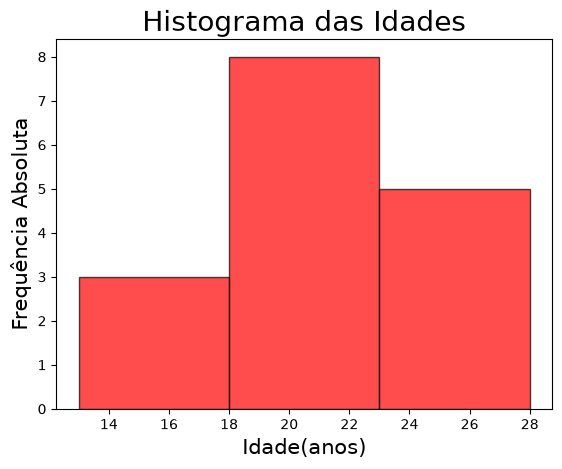

In [21]:
# Construindo o histograma da variável Idade informando a quantidade de classes pretendida. NO EXEMPLO BINS=3.
plt.hist(df.Idade, bins=3, rwidth=1, color='red', alpha=0.7, edgecolor='black')
# título e legendas
plt.title('Histograma das Idades', fontsize=20)
plt.xlabel('Idade(anos)', fontsize=15)
plt.ylabel('Frequência Absoluta', fontsize=15)
plt.tick_params(labelsize=10)
plt.show()


**Medidas de Tendência Central**

- Média, Moda e Mediana


In [22]:
# cálculo da Média, indicando Dataframe e a coluna em questão, no exemplo df.Idade
df.Idade.mean()


np.float64(20.5)

In [23]:
# cálculo da moda. Mesmas indicações
df.Idade.mode()


0    19
1    23
Name: Idade, dtype: int64

In [24]:
# cálculo da mediana.
df.Idade.median()


np.float64(20.5)

In [25]:
# para dado qualitativo, calculamos a moda
df.Sexo.mode()


0     fem
1    masc
Name: Sexo, dtype: str

In [26]:
df.Escolaridade.mode()


0       médio
1    superior
Name: Escolaridade, dtype: str

In [27]:
# para os dados do IBGE


In [28]:
# média para a coluna valor
dados.valor.mean()


np.float64(126.08333333333333)

In [29]:
# com 2 casas decimais
dados.valor.mean().round(2)


np.float64(126.08)

In [30]:
# moda para coluna valor
dados.valor.mode()


0    111
Name: valor, dtype: int64

In [31]:
# cálculo da mediana para coluna valor
dados.valor.median()


np.float64(125.0)

In [32]:
# comando describe mostra várias medidas das variáveis quantitativas, incluindo média e mediana.
df.Idade.describe().round(2)


count    16.00
mean     20.50
std       4.02
min      13.00
25%      18.75
50%      20.50
75%      23.00
max      28.00
Name: Idade, dtype: float64

In [33]:
dados.valor.describe().round(2)


count     12.00
mean     126.08
std       17.80
min       93.00
25%      111.00
50%      125.00
75%      142.00
max      149.00
Name: valor, dtype: float64